# Multiple Linear Regression — Gradient Descent from Scratch

**Goal:** Fit `y = w1*x1 + w2*x2 + ... + wn*xn + b` using vectorized batch gradient descent.

**Loss (MSE):**
$$J(\mathbf{w},b)=\frac{1}{2m}\sum_{i=1}^m(\hat y_i-y_i)^2,\quad \hat y = X\mathbf{w}+b$$

**Gradients (vectorized):**
$$\nabla_w J = \frac{1}{m}X^T(\hat y - y)\qquad \frac{\partial J}{\partial b}=\frac{1}{m}\sum(\hat y-y)$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

## 1. Dataset
Synthetic house-price-style dataset with 3 features: `size`, `bedrooms`, `age`.

In [2]:
m = 500
size = np.random.uniform(500, 3500, m)         # sq ft
bedrooms = np.random.randint(1, 6, m)
age = np.random.uniform(0, 40, m)               # years

noise = np.random.randn(m) * 15000
price = 50000 + 120*size + 8000*bedrooms - 900*age + noise

X = np.column_stack([size, bedrooms, age])
y = price

import pandas as pd
df = pd.DataFrame({"size": size, "bedrooms": bedrooms, "age": age, "price": price})
df.head()

,size,bedrooms,age,price
0,1623.620357,1,13.434634,257165.027602
1,3352.142919,1,33.004293,428135.159348
2,2695.981825,1,14.522368,392207.741497
3,2295.975453,5,1.369124,398901.717746
4,968.055921,4,33.226180,163438.801282


## 2. Preprocessing
Feature scaling is important for gradient descent to converge well when features have different scales.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 3. Loss function (MSE)

In [4]:
def compute_loss(X, y, w, b):
    m = len(y)
    y_pred = X @ w + b
    return (1/(2*m)) * np.sum((y_pred - y) ** 2)

## 4. Vectorized Gradient Descent

In [5]:
def gradient_descent_mlr(X, y, lr=0.1, epochs=1000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    loss_history = []

    for i in range(epochs):
        y_pred = X @ w + b
        error = y_pred - y

        dw = (1/m) * (X.T @ error)
        db = (1/m) * np.sum(error)

        w -= lr * dw
        b -= lr * db

        loss = compute_loss(X, y, w, b)
        loss_history.append(loss)

        if i % 100 == 0:
            print(f"Epoch {i:4d} | loss={loss:,.2f}")

    return w, b, loss_history

w, b, loss_history = gradient_descent_mlr(X_train_s, y_train, lr=0.1, epochs=1000)
print("\nWeights:", w, "| bias:", b)

Epoch    0 | loss=40,400,275,065.52
Epoch  100 | loss=114,659,706.73
Epoch  200 | loss=114,659,670.28
Epoch  300 | loss=114,659,670.28
Epoch  400 | loss=114,659,670.28
Epoch  500 | loss=114,659,670.28
Epoch  600 | loss=114,659,670.28
Epoch  700 | loss=114,659,670.28
Epoch  800 | loss=114,659,670.28
Epoch  900 | loss=114,659,670.28

Weights: [107910.10109251  10344.74582325  -9992.6111049 ] | bias: 296018.4463799286


## 5. Convergence plot

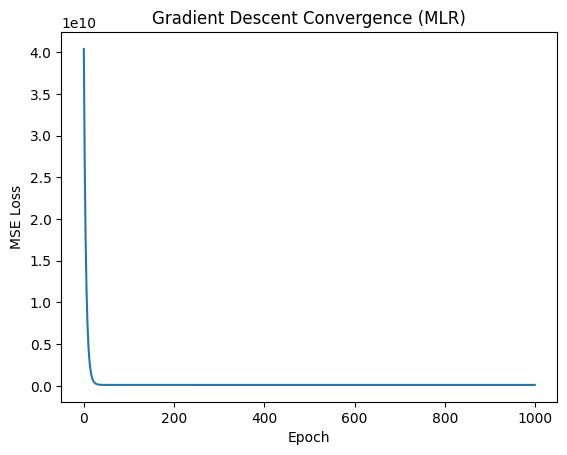

In [6]:
plt.plot(loss_history)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence (MLR)")
plt.show()

## 6. Evaluate on test set

In [7]:
y_pred_test = X_test_s @ w + b
print("Scratch MLR  -> MSE:", mean_squared_error(y_test, y_pred_test), " R2:", r2_score(y_test, y_pred_test))

model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred_sklearn = model.predict(X_test_s)
print("sklearn MLR  -> MSE:", mean_squared_error(y_test, y_pred_sklearn), " R2:", r2_score(y_test, y_pred_sklearn))

print("\nsklearn coef:", model.coef_, "intercept:", model.intercept_)
print("scratch coef:", w, "intercept:", b)

Scratch MLR  -> MSE: 246096884.27808484  R2: 0.9774827268699104
sklearn MLR  -> MSE: 246096884.27808407  R2: 0.9774827268699106

sklearn coef: [107910.10109251  10344.74582325  -9992.6111049 ] intercept: 296018.44637992885
scratch coef: [107910.10109251  10344.74582325  -9992.6111049 ] intercept: 296018.4463799286


## 7. Try it yourself
- Remove scaling and see how much slower/unstable gradient descent becomes.
- Add more features (e.g. `distance_to_city`).
- Try the **Normal Equation** solution and compare weights to gradient descent's.
